# Hidden Markov Models

To-do:
- Test HMMlearn python
- Look for other libraries


In [1]:
import numpy as np
from hmmlearn import hmm

In [2]:
np.random.seed(42)

model = hmm.GaussianHMM(n_components=3, covariance_type="full")
model.startprob_ = np.array([0.6, 0.3, 0.1])
model.transmat_ = np.array([[0.7, 0.2, 0.1],
                            [0.3, 0.5, 0.2],
                            [0.3, 0.3, 0.4]])
model.means_ = np.array([[0.0, 0.0], [3.0, -3.0], [5.0, 10.0]])
model.covars_ = np.tile(np.identity(2), (3, 1, 1))
X, Z = model.sample(100)

### Example code from hmmlearn website

/var/folders/x5/k71n0vsx49bbvxqh77hmyxc00000gn/T/ipykernel_46078/246583904.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


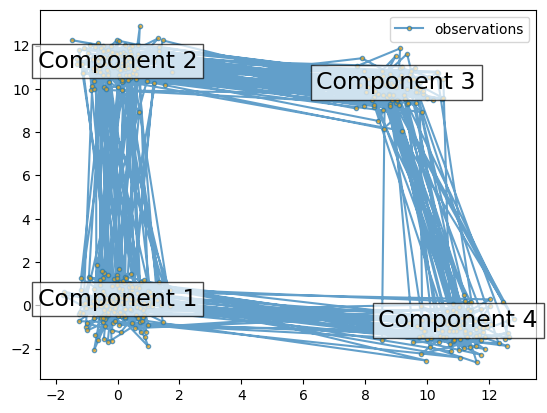

In [3]:
import matplotlib.pyplot as plt


# Prepare parameters for a 4-components HMM
# Initial population probability
startprob = np.array([0.6, 0.3, 0.1, 0.0])
# The transition matrix, note that there are no transitions possible
# between component 1 and 3
transmat = np.array([[0.7, 0.2, 0.0, 0.1],
                     [0.3, 0.5, 0.2, 0.0],
                     [0.0, 0.3, 0.5, 0.2],
                     [0.2, 0.0, 0.2, 0.6]])
# The means of each component
means = np.array([[0.0, 0.0],
                  [0.0, 11.0],
                  [9.0, 10.0],
                  [11.0, -1.0]])
# The covariance of each component
covars = .5 * np.tile(np.identity(2), (4, 1, 1))

# Build an HMM instance and set parameters
gen_model = hmm.GaussianHMM(n_components=4, covariance_type="full")

# Instead of fitting it from the data, we directly set the estimated
# parameters, the means and covariance of the components
gen_model.startprob_ = startprob
gen_model.transmat_ = transmat
gen_model.means_ = means
gen_model.covars_ = covars

# Generate samples
X, Z = gen_model.sample(500)

# Plot the sampled data
fig, ax = plt.subplots()
ax.plot(X[:, 0], X[:, 1], ".-", label="observations", ms=6,
        mfc="orange", alpha=0.7)

# Indicate the component numbers
for i, m in enumerate(means):
    ax.text(m[0], m[1], 'Component %i' % (i + 1),
            size=17, horizontalalignment='center',
            bbox=dict(alpha=.7, facecolor='w'))
ax.legend(loc='best')
fig.show()

In [4]:
scores = list()
models = list()
for n_components in (3, 4, 5):
    for idx in range(10):
        # define our hidden Markov model
        model = hmm.GaussianHMM(n_components=n_components,
                                covariance_type='full',
                                random_state=idx)
        model.fit(X[:X.shape[0] // 2])  # 50/50 train/validate
        models.append(model)
        scores.append(model.score(X[X.shape[0] // 2:]))
        print(f'Converged: {model.monitor_.converged}'
              f'\tScore: {scores[-1]}')

# get the best model
model = models[np.argmax(scores)]
n_states = model.n_components
print(f'The best model had a score of {max(scores)} and {n_states} '
      'states')

# use the Viterbi algorithm to predict the most likely sequence of states
# given the model
states = model.predict(X)

Converged: True	Score: -1538.0297029441722
Converged: True	Score: -1292.1207737103282
Converged: True	Score: -1023.19019278913
Converged: True	Score: -1033.5340236432535
Converged: True	Score: -1122.4692040691466
Converged: True	Score: -1033.5340236432596
Converged: True	Score: -1033.5340236432542
Converged: True	Score: -1033.5340236432526
Converged: True	Score: -1080.8094688238648
Converged: True	Score: -1033.5340236432507
Converged: True	Score: -905.5134814451498
Converged: True	Score: -1022.4682579819907
Converged: True	Score: -1016.5621440918363
Converged: True	Score: -878.314566051941
Converged: True	Score: -872.7830811315913
Converged: True	Score: -1032.3218951848992
Converged: True	Score: -1152.3581286745496
Converged: True	Score: -872.7970099535482
Converged: True	Score: -872.7830811315864
Converged: True	Score: -872.6901366431168
Converged: True	Score: -1110.941847485253
Converged: True	Score: -1242.4176956564377
Converged: True	Score: -893.5911604646683
Converged: True	Score:

/var/folders/x5/k71n0vsx49bbvxqh77hmyxc00000gn/T/ipykernel_46078/3426322113.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/x5/k71n0vsx49bbvxqh77hmyxc00000gn/T/ipykernel_46078/3426322113.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


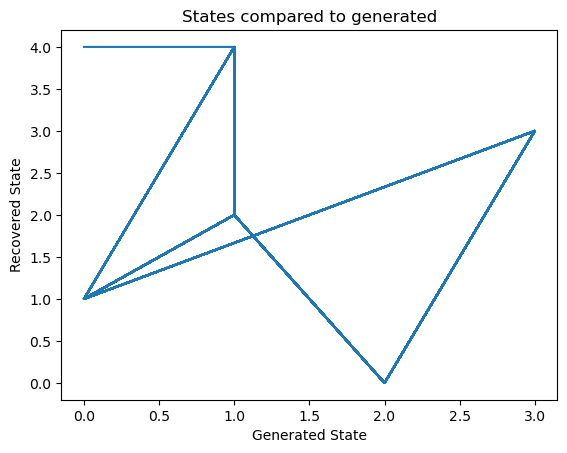

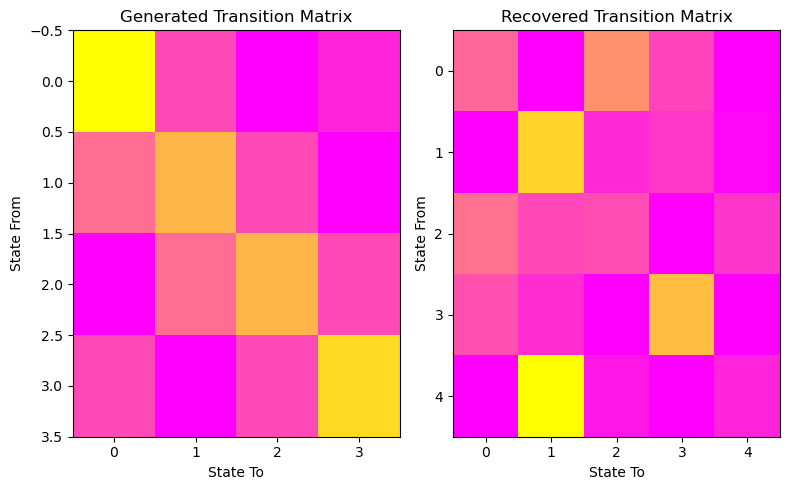

In [5]:
# plot model states over time
fig, ax = plt.subplots()
ax.plot(Z, states)
ax.set_title('States compared to generated')
ax.set_xlabel('Generated State')
ax.set_ylabel('Recovered State')
fig.show()

# plot the transition matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5))
ax1.imshow(gen_model.transmat_, aspect='auto', cmap='spring')
ax1.set_title('Generated Transition Matrix')
ax2.imshow(model.transmat_, aspect='auto', cmap='spring')
ax2.set_title('Recovered Transition Matrix')
for ax in (ax1, ax2):
    ax.set_xlabel('State To')
    ax.set_ylabel('State From')

fig.tight_layout()
fig.show()